# Capítulo 11 — Circulação Geral: laboratório numérico

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

| Caso | O que fazemos | Ferramenta |
|---|---|---|
| 1 | desequilíbrio radiativo → transporte exigido (os 5 PW) | NumPy |
| 2 | EBM meridional: $T(\phi)$ e a linha do gelo | `climlab` |
| 3 | ondas de Rossby: dispersão e a onda estacionária | NumPy |
| 4 | vento térmico → o jato numa seção meridional | NumPy |

Exercícios numéricos N1–N4 no fim; soluções em `cap11_solucoes.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

R_T, Omega, S0, g = 6.371e6, 7.292e-5, 1361.0, 9.8

## Caso 1 — Quanta energia precisa viajar para os polos?

Reaproveitamos a insolação diária do Cap. 2 (média anual), um albedo dependente da latitude e uma OLR quase plana. O transporte exigido é a integral acumulada do desequilíbrio:
$$T(\phi) = \int_{-90°}^{\phi} (Q_{abs} - OLR)\,2\pi R^2\cos\phi'\,d\phi'$$

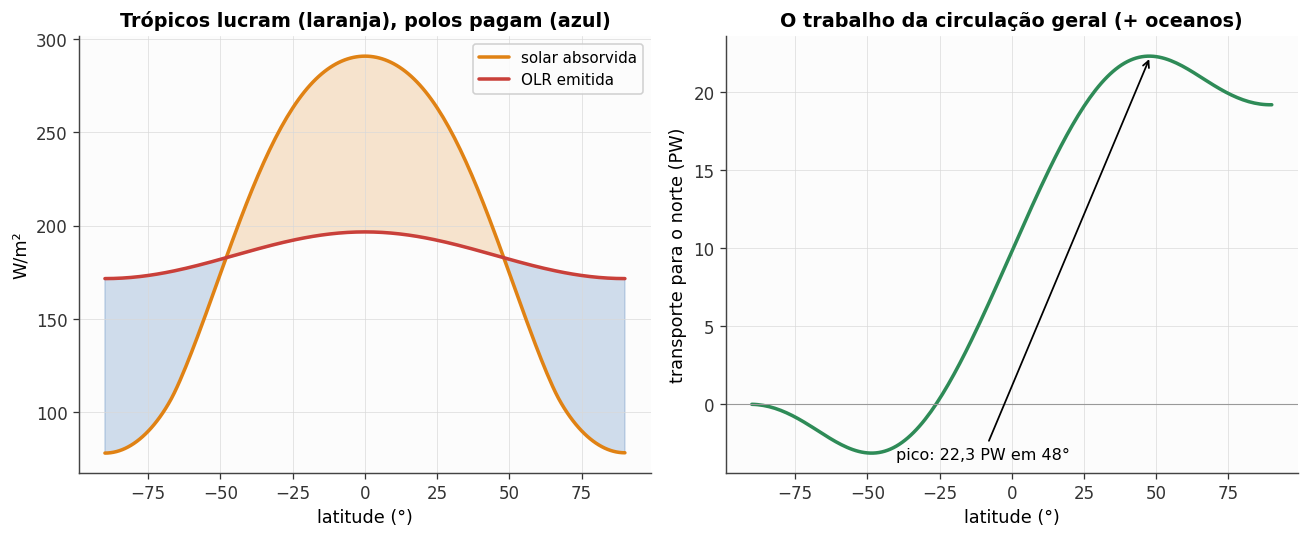

teste de consistência: transporte(90°N) = 19.18 PW (deve ≈ 0)


In [2]:
Phi_r, d_r, d_y = np.deg2rad(23.44), 173, 365.25
def insolacao_diaria(phi, d):
    dl = Phi_r*np.cos(2*np.pi*(d - d_r)/d_y)
    h0 = np.arccos(np.clip(-np.tan(phi)*np.tan(dl), -1, 1))
    return S0/np.pi*(h0*np.sin(phi)*np.sin(dl) + np.cos(phi)*np.cos(dl)*np.sin(h0))

lat = np.linspace(-90, 90, 181)
phi = np.deg2rad(lat)
dias = np.arange(1, 366)
Q_anual = np.array([np.mean([insolacao_diaria(p, d) for d in dias]) for p in phi])
albedo = 0.30 + 0.25*np.sin(phi)**4          # mais gelo/nuvens em latitudes altas
Q_abs = (1 - albedo)*Q_anual
OLR = 238.0 + 25.0*(np.cos(phi)**2 - 2/3)    # quase plana; média global = Q_abs média
OLR += Q_abs.mean() - np.average(OLR, weights=np.cos(phi))

desequilibrio = Q_abs - OLR
dphi = np.deg2rad(lat[1] - lat[0])
transporte = np.cumsum(desequilibrio*2*np.pi*R_T**2*np.cos(phi)*dphi)/1e15  # PW

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.8))
ax1.plot(lat, Q_abs, color=CORES['laranja'], label='solar absorvida')
ax1.plot(lat, OLR, color=CORES['vermelho'], label='OLR emitida')
ax1.fill_between(lat, Q_abs, OLR, where=Q_abs > OLR, color=CORES['laranja'],
                 alpha=0.2)
ax1.fill_between(lat, Q_abs, OLR, where=Q_abs < OLR, color=CORES['azul'],
                 alpha=0.2)
ax1.set(xlabel='latitude (°)', ylabel='W/m²',
        title='Trópicos lucram (laranja), polos pagam (azul)')
ax1.legend()
ax2.plot(lat, transporte, color=CORES['verde'])
ax2.axhline(0, color='#999999', lw=0.7)
i_max = np.argmax(np.abs(transporte))
ax2.annotate(f'pico: {abs(transporte[i_max]):.1f} PW em {abs(lat[i_max]):.0f}°'
             .replace('.', ','),
             xy=(lat[i_max], transporte[i_max]), xytext=(-40, -3.5),
             fontsize=10, arrowprops=dict(arrowstyle='->', lw=1.1))
ax2.set(xlabel='latitude (°)', ylabel='transporte para o norte (PW)',
        title='O trabalho da circulação geral (+ oceanos)')
fig.tight_layout(); plt.show()
print(f'teste de consistência: transporte(90°N) = {transporte[-1]:.2f} PW (deve ≈ 0)')

## Caso 2 — O EBM meridional do `climlab`: $T(\phi)$ e a linha do gelo

O modelo de balanço de energia com difusão meridional — o modelo climático mais simples que ainda acerta o gradiente equador–polo. A difusividade $D$ representa toda a circulação geral num único número.

Integrating for 900 steps, 3652.4220000000005 days, or 10 years.


Total elapsed time is 9.999999999999863 years.
Integrating for 900 steps, 3652.4220000000005 days, or 10 years.


Total elapsed time is 9.999999999999863 years.
Integrating for 900 steps, 3652.4220000000005 days, or 10 years.


Total elapsed time is 9.999999999999863 years.


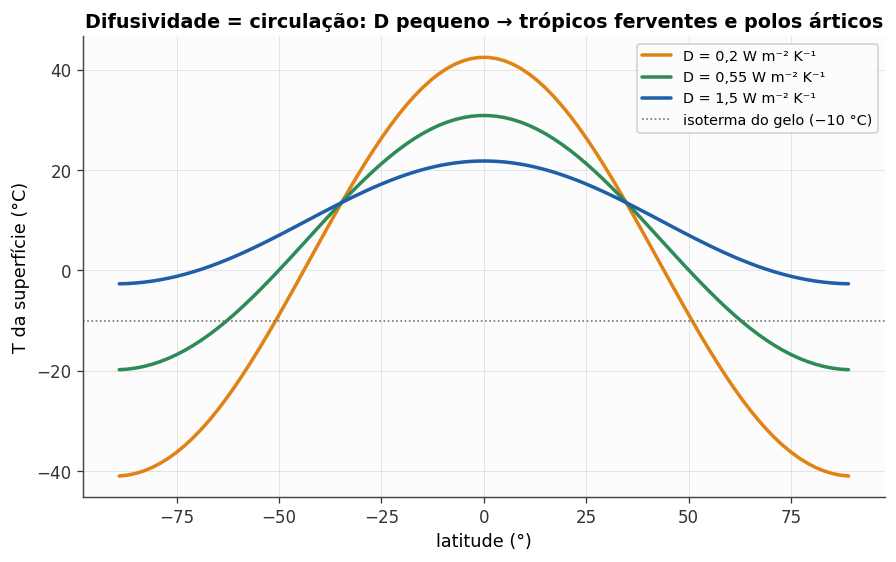

Integrating for 900 steps, 3652.4220000000005 days, or 10 years.


Total elapsed time is 9.999999999999863 years.
D=0,55: T(equador) = 30.8 °C | T(polo sul) = -19.8 °C | gradiente = 51 K (observado ~45 K) ✓


In [3]:
import warnings
warnings.filterwarnings('ignore', message='Cannot import')
import climlab

fig, ax = plt.subplots(figsize=(9, 5.2))
for D, cor in [(0.2, CORES['laranja']), (0.55, CORES['verde']),
               (1.5, CORES['azul'])]:
    ebm = climlab.EBM_annual(num_lat=90, D=D)
    ebm.integrate_years(10)
    Ts = np.squeeze(ebm.Ts)
    ax.plot(ebm.lat, Ts, color=cor,
            label=f'D = {D} W m⁻² K⁻¹'.replace('.', ','))
    gelo = ebm.lat[np.abs(Ts + 10).argmin()]   # linha do gelo ~ -10 °C
ax.axhline(-10, color=CORES['cinza'], ls=':', lw=1,
           label='isoterma do gelo (−10 °C)')
ax.set(xlabel='latitude (°)', ylabel='T da superfície (°C)',
       title='Difusividade = circulação: D pequeno → trópicos ferventes e polos árticos')
ax.legend(fontsize=9)
plt.show()

ebm = climlab.EBM_annual(num_lat=90, D=0.55)
ebm.integrate_years(10)
Ts = np.squeeze(ebm.Ts)
print(f'D=0,55: T(equador) = {Ts[45]:.1f} °C | T(polo sul) = {Ts[0]:.1f} °C | '
      f'gradiente = {Ts[45]-Ts[0]:.0f} K (observado ~45 K) ✓')

## Caso 3 — Ondas de Rossby: quem anda para onde

$$c = U - \frac{\beta}{k^2},\qquad k = \frac{2\pi}{\lambda},\qquad \lambda_{est} = 2\pi\sqrt{U/\beta}$$

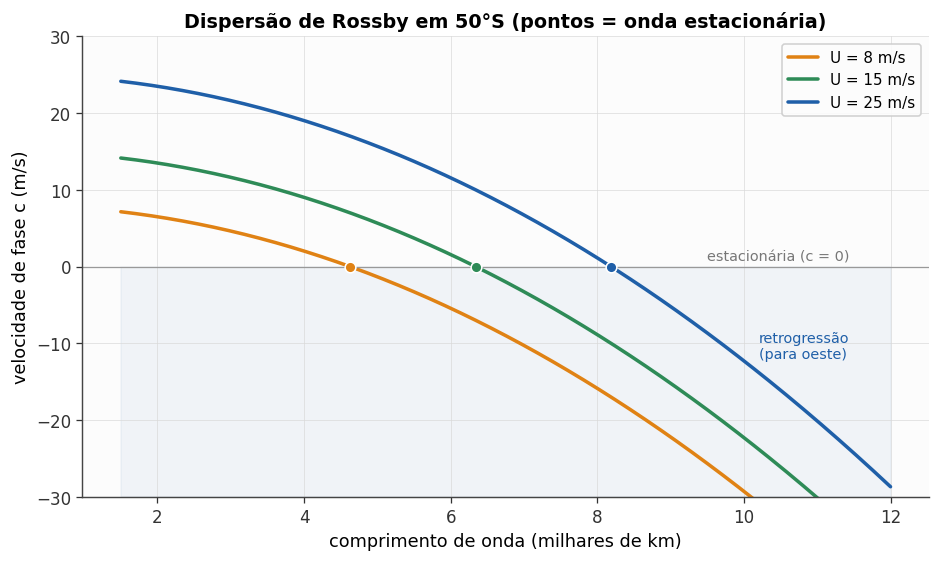

U =  8 m/s: λ_est = 4.6 mil km → 5.6 ondas na latitude
U = 15 m/s: λ_est = 6.3 mil km → 4.1 ondas na latitude
U = 25 m/s: λ_est = 8.2 mil km → 3.1 ondas na latitude


In [4]:
phi0 = -50.0
beta = 2*Omega*np.cos(np.deg2rad(phi0))/R_T
circunf = 2*np.pi*R_T*np.cos(np.deg2rad(phi0))

lam = np.linspace(1500e3, 12000e3, 400)
k = 2*np.pi/lam

fig, ax = plt.subplots(figsize=(9.5, 5.2))
for U, cor in [(8, CORES['laranja']), (15, CORES['verde']), (25, CORES['azul'])]:
    c = U - beta/k**2
    ax.plot(lam/1e6, c, color=cor, label=f'U = {U} m/s')
    lam_est = 2*np.pi*np.sqrt(U/beta)
    ax.scatter([lam_est/1e6], [0], color=cor, zorder=5, s=45,
               edgecolor='white')
ax.axhline(0, color='#999999', lw=0.8)
ax.text(9.5, 0.8, 'estacionária (c = 0)', fontsize=9, color='#777777')
ax.fill_between(lam/1e6, -30, 0, color=CORES['azul'], alpha=0.05)
ax.text(10.2, -12, 'retrogressão\n(para oeste)', fontsize=9,
        color=CORES['azul'])
ax.set(xlabel='comprimento de onda (milhares de km)',
       ylabel='velocidade de fase c (m/s)', ylim=(-30, 30),
       title=f'Dispersão de Rossby em {abs(phi0):.0f}°S '
             '(pontos = onda estacionária)')
ax.legend()
plt.show()
for U in [8, 15, 25]:
    lam_est = 2*np.pi*np.sqrt(U/beta)
    print(f'U = {U:2d} m/s: λ_est = {lam_est/1e6:.1f} mil km → '
          f'{circunf/lam_est:.1f} ondas na latitude')

## Caso 4 — O jato nasce do contraste: vento térmico em ação

$$\frac{\partial u_g}{\partial z} = -\frac{g}{f\,T}\frac{\partial T}{\partial y}$$

Seção meridional idealizada do HS com zona baroclínica em 50°S: integramos da superfície para cima e o jato aparece sozinho na tropopausa.

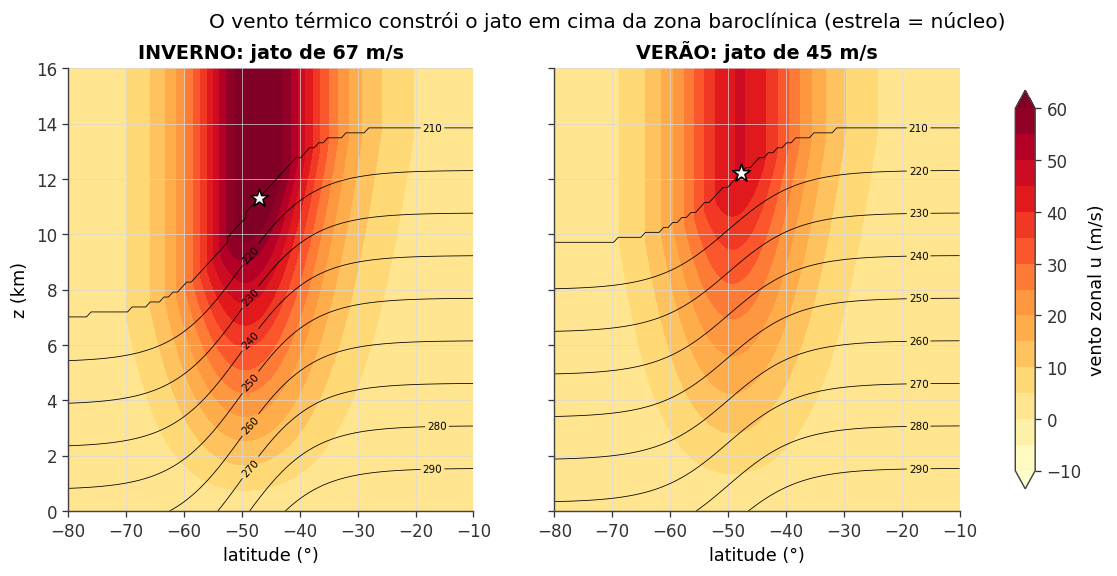

In [5]:
lat_g = np.linspace(-80, -10, 90)
z_g = np.linspace(0, 16e3, 90)
LAT, Z = np.meshgrid(lat_g, z_g)

def T_field(inverno=True):
    dT = 45.0 if inverno else 28.0            # contraste equador-polo
    T_sfc = 300.0 - dT*0.5*(1 + np.tanh((LAT + 50)/(-12)))
    gamma = 6.5e-3
    T = T_sfc - gamma*Z
    T = np.maximum(T, 210.0)                   # estratosfera isotérmica
    return T

def jato(T):
    f = 2*Omega*np.sin(np.deg2rad(LAT))
    dTdy = np.gradient(T, np.deg2rad(lat_g)*R_T, axis=1)
    dudz = -g/(f*T)*dTdy
    u = np.cumsum(dudz, axis=0)*(z_g[1] - z_g[0])
    return u

fig, axs = plt.subplots(1, 2, figsize=(12.5, 5), sharey=True)
for ax, inverno in [(axs[0], True), (axs[1], False)]:
    T = T_field(inverno)
    u = jato(T)
    cf = ax.contourf(LAT, Z/1e3, u, levels=np.arange(-10, 61, 5),
                     cmap='YlOrRd', extend='both')
    cs = ax.contour(LAT, Z/1e3, T, levels=np.arange(210, 301, 10),
                    colors='k', linewidths=0.5)
    ax.clabel(cs, fmt='%d', fontsize=6.5)
    i, j = np.unravel_index(np.argmax(u), u.shape)
    ax.scatter([lat_g[j]], [z_g[i]/1e3], marker='*', s=140, color='white',
               edgecolor='k', zorder=5)
    ax.set(xlabel='latitude (°)',
           title=f"{'INVERNO' if inverno else 'VERÃO'}: jato de {u.max():.0f} m/s")
axs[0].set_ylabel('z (km)')
fig.colorbar(cf, ax=axs, label='vento zonal u (m/s)', shrink=0.9)
fig.suptitle('O vento térmico constrói o jato em cima da zona baroclínica (estrela = núcleo)')
plt.show()

---
## Exercícios numéricos complementares

Enunciados completos (e teóricos T1–T5) nas notas de aula; **soluções em `cap11_solucoes.ipynb`**.

**N1** — No Caso 1, imponha albedo de gelo ($A = 0{,}6$) além de ±70° e recalcule o transporte; compare pico e posição.

**N2** — No Caso 2, varra $D$ de 0,1 a 2,0 e trace: (a) gradiente equador–polo; (b) latitude da isoterma de −10 °C. Interprete os limites.

**N3** — Ache numericamente o $k$ estacionário para $U$ de 5 a 30 m/s e compare com $2\pi\sqrt{U/\beta}$; trace o número de ondas na latitude 50°S.

**N4** — No Caso 4, dobre a largura da zona baroclínica (tanh com escala 24° em vez de 12°) e compare intensidade e altura do jato; explique via vento térmico.

In [6]:
# N1 — sua solução aqui


In [7]:
# N2 — sua solução aqui


In [8]:
# N3 — sua solução aqui


In [9]:
# N4 — sua solução aqui


---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*